# Разведочный анализ и кластеризация каналов датчиков

Задача 8 «Международного хакатона 2026», АО «Москоллектор».

Тетрадь отвечает на один вопрос: **какие группы каналов ведут себя по-разному и
какие из этих групп интересны для прогнозирования инцидентов.**

Порядок работы такой.

1. Загрузить выгрузку и проверить её объём.
2. Посмотреть на данные: годы, словарь тревог, дерево объектов, артефакт 2021 года.
3. Построить признаки поведения канала. Признаки описывают, **как** канал ведёт
   себя во времени, а не **чем** он является.
4. Свернуть признаки в две координаты через UMAP.
5. Разбить точки на кластеры через HDBSCAN.
6. Прочитать кластеры и отобрать интересные.
7. Найти каналы, которые ведут себя не как их собственный тип датчика.

Выводы тетради лежат в `hackathon-gap-analysis.md`. Здесь ход работы.

Правило разбиения выборки по времени к этой тетради не относится: кластеризация
не обучается на метке и прогноз не строит. Она даёт описание сети.

In [1]:
# Воспроизводимость. Переменные надо ставить до импорта umba и numba, иначе они
# не подействуют: numba читает их один раз при загрузке.
#
# Без NUMBA_NUM_THREADS=1 UMAP даёт разную раскладку от запуска к запуску, даже
# когда random_state задан. Параллельная редукция складывает числа в разном
# порядке, и HDBSCAN потом находит то 15 кластеров, то 25. Проверено: три
# процесса подряд давали три разных результата. Скорость теряем, повторяемость
# получаем, и на защите это важнее.
import os

os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["PYTHONHASHSEED"] = "0"

import sys, time, warnings, json, hashlib
from pathlib import Path

warnings.filterwarnings("ignore")

SEED = 42

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATASET = ROOT / "raw_task" / "dataset"
PARQUET = ROOT / "eda" / "out" / "events.parquet"
OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

print("корень:", ROOT)
print("выгрузка:", DATASET.exists())
print("parquet:", PARQUET.exists())
print("версии:", f"duckdb {duckdb.__version__}", f"pandas {pd.__version__}", f"numpy {np.__version__}")

корень: C:\Users\IshikiI\Desktop\Coding\Hackathons\LCT2026\LCT2026
выгрузка: True
parquet: True
версии: duckdb 1.5.5 pandas 3.0.5 numpy 2.5.3


## Оформление графиков

Тёмная схема, как в интерфейсе диспетчера. Шкала риска повторяет токены
`--risk-*` из `frontend/src/styles/tokens.css`, чтобы картинки тетради и экраны
сервиса говорили на одном языке цвета.

In [2]:
BG, PANEL, LINE, TEXT, DIM = "#161C22", "#1D242B", "#2E3841", "#E4E9ED", "#9AA8B4"
RISK = ["#3E8C74", "#C89230", "#D4602F", "#C43B36"]
ACCENT = ["#6f8fb5", "#c96a3a", "#a884c0", "#4a7fb5", "#5f9ea0"]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL, "savefig.facecolor": BG,
    "text.color": TEXT, "axes.labelcolor": DIM, "axes.edgecolor": LINE,
    "xtick.color": DIM, "ytick.color": DIM, "grid.color": LINE,
    "axes.grid": True, "grid.alpha": 0.35, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9, "figure.dpi": 110,
})


def million(x, _=None):
    return f"{x/1e6:.0f} млн" if x >= 1e6 else f"{x/1e3:.0f} тыс" if x >= 1e3 else f"{x:.0f}"

## 1. Загрузка

Журнал весит 15,9 ГБ в восьми CSV. Читать его построчно нельзя: часть значений
содержит запятые и переносы строк. Файл `ext-journal-2025.csv` к тому же несёт
повторный заголовок в середине, на границе полугодия.

DuckDB переводит журнал в parquet одним проходом примерно за 23 секунды.
Результат весит 1,82 ГБ, и дальше все запросы идут по нему. Если parquet уже
лежит на месте, ячейка его переиспользует.

In [3]:
con = duckdb.connect()
con.execute("PRAGMA threads=8")

if not PARQUET.exists():
    PARQUET.parent.mkdir(parents=True, exist_ok=True)
    t0 = time.time()
    con.execute(f"""
        COPY (
          SELECT
            TRY_CAST(ид_события AS BIGINT)        AS event_id,
            TRY_CAST(ид_канала_данных AS BIGINT)  AS channel_id,
            TRY_CAST(дата AS DATE)                AS d,
            TRY_CAST(время AS TIME)               AS t,
            (тревожное IN ('t', 'true', 'True'))  AS alarm,
            значение                              AS value
          FROM read_csv_auto('{(DATASET / "ext-journal-*.csv").as_posix()}',
                             header=true, union_by_name=true, all_varchar=true)
          WHERE TRY_CAST(ид_события AS BIGINT) IS NOT NULL
        ) TO '{PARQUET.as_posix()}' (FORMAT PARQUET, COMPRESSION ZSTD)
    """)
    print("собрано за", round(time.time() - t0, 1), "с")

con.execute(f"CREATE VIEW ev AS SELECT * FROM '{PARQUET.as_posix()}'")
con.execute(f"""CREATE VIEW ch AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_каналов_датчиков.csv').as_posix()}', header=true)""")
con.execute(f"""CREATE VIEW ob AS SELECT * FROM read_csv_auto(
    '{(DATASET / 'справочник_объектов_диспетчер.csv').as_posix()}', header=true)""")

rows = con.sql("SELECT count(*) FROM ev").fetchone()[0]
print(f"записей журнала: {rows:,}".replace(",", " "))
print("каналов в справочнике:", con.sql("SELECT count(*) FROM ch").fetchone()[0])
print("узлов дерева объектов:", con.sql("SELECT count(*) FROM ob").fetchone()[0])

записей журнала: 313 546 016
каналов в справочнике: 11485
узлов дерева объектов: 95


## 2. Что внутри

### 2.1. Дерево замыкается

Справочник каналов обновлён 16 сентября: заказчик добавил поле `ид_объект`.
До этого связи между каналом и объектом не было вовсе, и её приходилось
восстанавливать по номерам пикетов в названиях. Проверяем, что связь полная.

In [4]:
link = con.sql("""
SELECT count(*) AS каналов,
       count(c.ид_объект) AS с_объектом,
       count(o.ид_объект) AS объект_найден,
       count(DISTINCT c.ид_объект) AS объектов
FROM ch c LEFT JOIN ob o ON o.ид_объект = c.ид_объект
""").df()
display(link)

tree = con.sql("""
SELECT иерархия_уровень AS уровень, вид_объекта AS вид, count(*) AS узлов
FROM ob GROUP BY 1, 2 ORDER BY 1, 2
""").df()
display(tree)

,каналов,с_объектом,объект_найден,объектов
0,11485,11485,11485,78


,уровень,вид,узлов
0,1,district,1
1,2,controlHouse,16
2,3,controlHouse,49
3,3,guardObject,29


Связь полная: все 11 485 каналов получают объект, и каждый объект существует в
дереве. Иерархия из трёх уровней: один район, 16 комплексов, 78 объектов.

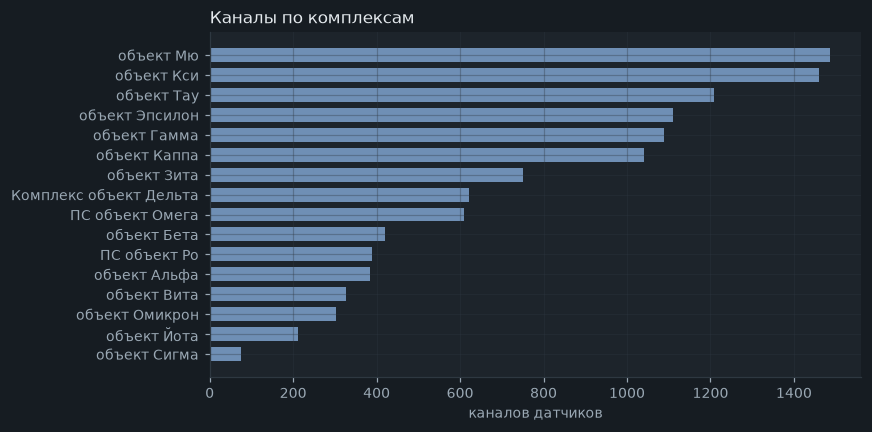

всего каналов: 11485 | объектов: 78


In [5]:
by_complex = con.sql("""
SELECT p.диспетчерское_название_объекта AS комплекс,
       count(DISTINCT o.ид_объект) AS объектов,
       count(c.ид_канала_данных)   AS каналов
FROM ob o
JOIN ob p ON o.родитель = p.ид_объект
LEFT JOIN ch c ON c.ид_объект = o.ид_объект
WHERE o.иерархия_уровень = 3
GROUP BY 1 ORDER BY каналов DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_complex.комплекс[::-1], by_complex.каналов[::-1], color=ACCENT[0], height=0.7)
ax.set_xlabel("каналов датчиков")
ax.set_title("Каналы по комплексам", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

print("всего каналов:", by_complex.каналов.sum(), "| объектов:", by_complex.объектов.sum())

### 2.2. Годы и доля тревог

Сеть росла все 7,5 года, а доля тревожных записей скакала в десять раз. Средняя
доля обманчива, и обучать модель на всём периоде без поправки нельзя.

,год,строк,тревог,доля,каналов
0,2019,"20,993,328","134,199",0.639 %,5622
1,2020,"28,172,398","325,662",1.156 %,7250
2,2021,"53,698,948","1,199,639",2.234 %,8625
3,2022,"43,483,149","133,504",0.307 %,10722
4,2023,"31,937,125","107,712",0.337 %,10400
5,2024,"49,023,883","115,203",0.235 %,10348
6,2025,"55,541,796","256,471",0.462 %,11483
7,2026,"30,695,389","195,422",0.637 %,11447


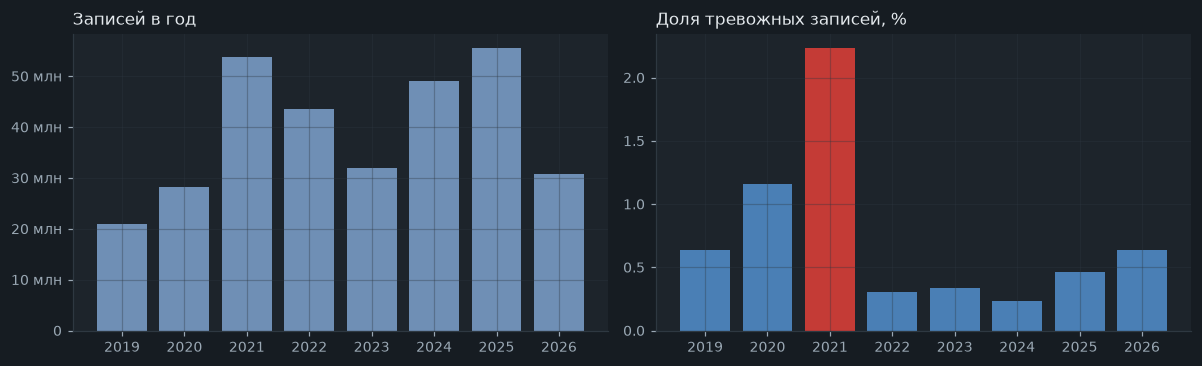

In [6]:
years = con.sql("""
SELECT year(d) AS год,
       count(*) AS строк,
       sum(CASE WHEN alarm THEN 1 ELSE 0 END) AS тревог,
       100.0 * sum(CASE WHEN alarm THEN 1 ELSE 0 END) / count(*) AS доля,
       count(DISTINCT channel_id) AS каналов
FROM ev GROUP BY 1 ORDER BY 1
""").df()
display(years.style.format({"строк": "{:,.0f}", "тревог": "{:,.0f}", "доля": "{:.3f} %"}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.bar(years.год, years.строк, color=ACCENT[0])
a1.set_title("Записей в год", loc="left", color=TEXT)
a1.yaxis.set_major_formatter(plt.FuncFormatter(million))
a2.bar(years.год, years.доля, color=[RISK[3] if y == 2021 else ACCENT[3] for y in years.год])
a2.set_title("Доля тревожных записей, %", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

### 2.3. Всплеск 2021 года это один объект

Заказчик на QA-сессии объяснил причину: в 2021 году внедряли новую версию
системы мониторинга, две системы работали параллельно, и люди не снимали
объекты с охраны.

Проверяем ответ по данным. Если причина общая, всплеск размажется по сети.

,год,тревог_всего,объект_5343,доля_5343
0,2019,118985,0,0.0
1,2020,241416,102127,42.3
2,2021,1158418,1053135,90.9
3,2022,125844,662,0.5
4,2023,105085,608,0.6
5,2024,114562,891,0.8
6,2025,256349,23903,9.3
7,2026,195413,23459,12.0


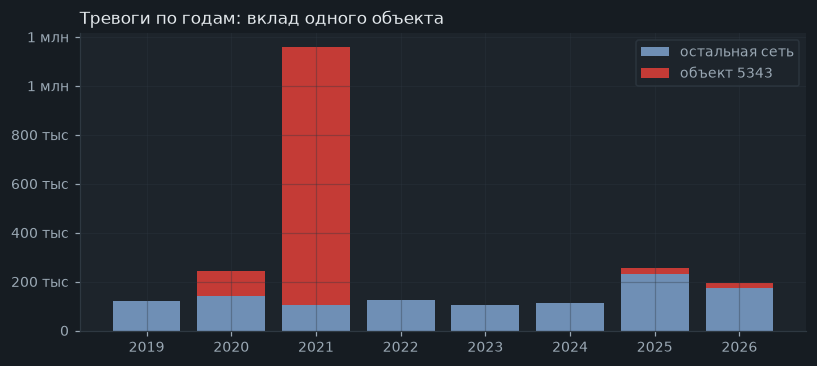

In [7]:
spike = con.sql("""
SELECT year(e.d) AS год,
       count(*) FILTER (WHERE e.alarm) AS тревог_всего,
       count(*) FILTER (WHERE e.alarm AND c.ид_объект = 5343) AS объект_5343
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
GROUP BY 1 ORDER BY 1
""").df()
spike["доля_5343"] = (100 * spike.объект_5343 / spike.тревог_всего).round(1)
display(spike)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.bar(spike.год, spike.тревог_всего - spike.объект_5343, color=ACCENT[0], label="остальная сеть")
ax.bar(spike.год, spike.объект_5343, bottom=spike.тревог_всего - spike.объект_5343,
       color=RISK[3], label="объект 5343")
ax.yaxis.set_major_formatter(plt.FuncFormatter(million))
ax.set_title("Тревоги по годам: вклад одного объекта", loc="left", color=TEXT)
ax.legend(facecolor=PANEL, edgecolor=LINE, labelcolor=DIM)
plt.tight_layout(); plt.show()

In [8]:
what = con.sql("""
SELECT e.value AS значение, count(*) AS записей
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE e.alarm AND c.ид_объект = 5343 AND year(e.d) IN (2020, 2021)
GROUP BY 1 ORDER BY записей DESC LIMIT 5
""").df()
display(what)
print("каналов задето:", con.sql("""
SELECT count(DISTINCT e.channel_id) FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE e.alarm AND c.ид_объект = 5343 AND year(e.d) IN (2020, 2021)""").fetchone()[0])

,значение,записей
0,Неисправен,1036606
1,Обнаружено движение,95305
2,Не замкнут,20600
3,Обнаружен дым,2298
4,Рычаг сдернут,187


каналов задето: 361


Всплеск не размазан по сети. Его даёт объект 5343 (`объект Кси ПК202-ПК302`):
1 036 606 записей «Неисправен» на 361 канале за 2020 и 2021 годы. Это 73 % всех
записей «Неисправен» за всю выгрузку.

**Вывод для обучения.** Выбрасывать надо один объект за два года, а не два года
целиком. Тогда 2019 и 2024 годы сходятся, и данные остальной сети за 2020 и 2021
остаются в работе.

Дальше все расчёты идут без этого артефакта.

In [9]:
con.execute("""
CREATE OR REPLACE VIEW base AS
SELECT e.channel_id AS cid, e.d AS dd, e.t AS tt, e.alarm AS alarm, e.value AS val
FROM ev e JOIN ch c ON c.ид_канала_данных = e.channel_id
WHERE NOT (c.ид_объект = 5343 AND year(e.d) IN (2020, 2021))
""")
kept = con.sql("SELECT count(*), sum(CASE WHEN alarm THEN 1 ELSE 0 END) FROM base").fetchone()
print(f"осталось записей: {kept[0]:,}".replace(",", " "))
print(f"осталось тревог:  {kept[1]:,}".replace(",", " "))

осталось записей: 301 660 881
осталось тревог:  1 160 810


### 2.4. Словарь тревог

Тревожных значений всего шестнадцать. Каждое ложится в направление
прогнозирования, и это единственный источник разметки: журнала ОДС с решениями
диспетчера заказчик не передаст.

Важная тонкость: **текст значения не равен тревоге**. Строка «Обнаружен дым»
встречается в журнале 195 955 раз, а тревожной является только 42 433 раза.
Событие определяет флаг, а не текст.

In [10]:
vocab = con.sql("""
SELECT val AS значение,
       count(*) FILTER (WHERE alarm) AS тревожных,
       count(*) AS всего_записей,
       count(DISTINCT cid) FILTER (WHERE alarm) AS каналов
FROM base
WHERE val IN (SELECT val FROM base WHERE alarm GROUP BY 1)
GROUP BY 1 ORDER BY тревожных DESC
""").df()
vocab = vocab[vocab.тревожных > 0]
display(vocab)

,значение,тревожных,всего_записей,каналов
0,Неисправен,380760,451030,3717
1,Не замкнут,266873,2553705,1900
2,Обесточен,160368,1243428,415
3,Обнаружено движение,108085,25525844,813
4,Работают все насосы в АНС,80366,80800,51
5,Затоплен,53679,62285,178
6,Обнаружен дым,40135,161457,4337
7,Питание от батарей,20125,20402,80
8,Обнаружен газ,10089,17820,529
9,Не определено,9195,10337,399


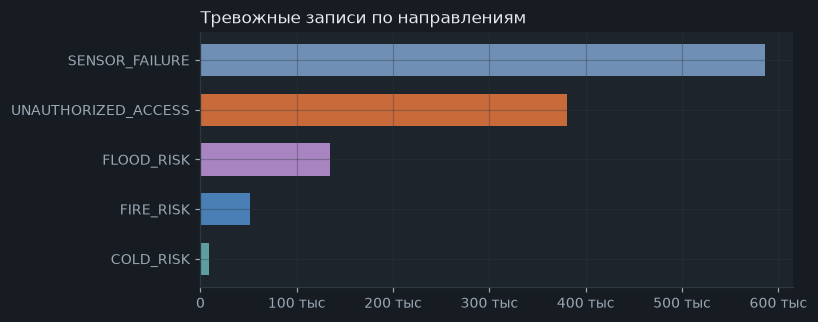

,тревожных
направление,
SENSOR_FAILURE,586125
UNAUTHORIZED_ACCESS,380245
FLOOD_RISK,134045
FIRE_RISK,51726
COLD_RISK,8669


In [11]:
DIRECTIONS = {
    "SENSOR_FAILURE": ["Неисправен", "Обесточен", "Питание от батарей", "Не определено",
                       "Много неисправных устройств", "Отключено устройство", "Батарея разряжена"],
    "UNAUTHORIZED_ACCESS": ["Не замкнут", "Обнаружено движение", "Рычаг сдернут"],
    "FLOOD_RISK": ["Работают все насосы в АНС", "Затоплен"],
    "FIRE_RISK": ["Обнаружен дым", "Обнаружен газ", "Температура выше 40ºC"],
    "COLD_RISK": ["Температура ниже 3ºC"],
}
VALUE_TO_DIR = {v: k for k, vs in DIRECTIONS.items() for v in vs}
assert set(VALUE_TO_DIR) >= set(vocab.значение), set(vocab.значение) - set(VALUE_TO_DIR)

vocab["направление"] = vocab.значение.map(VALUE_TO_DIR)
by_dir = vocab.groupby("направление").тревожных.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.barh(by_dir.index[::-1], by_dir.values[::-1], color=ACCENT[:len(by_dir)][::-1], height=0.65)
ax.xaxis.set_major_formatter(plt.FuncFormatter(million))
ax.set_title("Тревожные записи по направлениям", loc="left", color=TEXT)
plt.tight_layout(); plt.show()
display(by_dir.to_frame("тревожных"))

## 3. Признаки

Единица наблюдения это канал данных датчика, 11 485 штук. Канал выбран потому,
что он самый мелкий объект с историей. Единица прогноза в сервисе крупнее, это
пара «объект и пикет», и признаки кластера переносятся на неё агрегацией.

Признаки делятся на две группы, и это разделение принципиально.

**Поведение.** Как канал ведёт себя во времени: как часто пишет, как часто
тревожит, слипаются ли тревоги в пачки, повторяются ли назавтра, в какое время
суток и года приходят. Эти признаки не знают, что за датчик стоит.

**Природа.** Чем канал является: инженерная система, тип датчика, доля тревог
каждого направления.

Кластеризация идёт **только по поведению**. Если добавить природу, UMAP просто
перерисует справочник типов датчиков, и ничего нового мы не узнаем. А вот когда
поведенческий кластер собирает в себя разные типы датчиков, это уже находка.

In [12]:
t0 = time.time()

FEATURE_SQL = """
WITH f_rec AS (
  SELECT cid,
         count(*)                                   AS rec_n,
         sum(CASE WHEN alarm THEN 1 ELSE 0 END)     AS alarm_n,
         count(DISTINCT dd)                         AS active_days,
         min(dd) AS first_d, max(dd) AS last_d,
         count(DISTINCT val)                        AS val_kinds,
         avg(CASE WHEN hour(tt) < 6 THEN 1.0 ELSE 0.0 END)           AS night_share,
         avg(CASE WHEN dayofweek(dd) IN (0, 6) THEN 1.0 ELSE 0.0 END) AS weekend_share
  FROM base GROUP BY cid
),
f_al AS (
  SELECT cid,
         count(DISTINCT dd) AS alarm_days,
         max(n_day)         AS max_day_alarms,
         avg(CASE WHEN hour(tt) < 6 THEN 1.0 ELSE 0.0 END)            AS a_night_share,
         avg(CASE WHEN dayofweek(dd) IN (0, 6) THEN 1.0 ELSE 0.0 END) AS a_weekend_share,
         avg(CASE WHEN month(dd) IN (12, 1, 2) THEN 1.0 ELSE 0.0 END) AS a_winter_share
  FROM (SELECT cid, dd, tt, count(*) OVER (PARTITION BY cid, dd) AS n_day
        FROM base WHERE alarm)
  GROUP BY cid
),
f_seq AS (
  SELECT cid,
         avg(CASE WHEN gap = 1 THEN 1.0 ELSE 0.0 END) AS persistence,
         median(gap)                                   AS med_gap
  FROM (SELECT cid, date_diff('day', dd, lead(dd) OVER (PARTITION BY cid ORDER BY dd)) AS gap
        FROM (SELECT DISTINCT cid, dd FROM base WHERE alarm))
  WHERE gap IS NOT NULL GROUP BY cid
),
f_burst AS (
  SELECT cid, max(n) AS max_same_second
  FROM (SELECT cid, dd, tt, count(*) AS n FROM base WHERE alarm GROUP BY 1, 2, 3)
  GROUP BY cid
),
f_dir AS (
  SELECT cid,
    sum(CASE WHEN val IN ('Неисправен','Обесточен','Питание от батарей','Не определено',
        'Много неисправных устройств','Отключено устройство','Батарея разряжена')
        THEN 1 ELSE 0 END) AS a_fail,
    sum(CASE WHEN val IN ('Не замкнут','Обнаружено движение','Рычаг сдернут')
        THEN 1 ELSE 0 END) AS a_access,
    sum(CASE WHEN val IN ('Работают все насосы в АНС','Затоплен')
        THEN 1 ELSE 0 END) AS a_flood,
    sum(CASE WHEN val IN ('Обнаружен дым','Обнаружен газ','Температура выше 40ºC')
        THEN 1 ELSE 0 END) AS a_fire,
    sum(CASE WHEN val = 'Температура ниже 3ºC' THEN 1 ELSE 0 END) AS a_cold
  FROM base WHERE alarm GROUP BY cid
)
SELECT c.ид_канала_данных AS cid,
       c.тип_инж_системы  AS sys,
       c.тип_датчика      AS stype,
       c.название_датчика AS nm,
       c.ид_объект        AS oid,
       r.rec_n, r.alarm_n, r.active_days, r.first_d, r.last_d, r.val_kinds,
       r.night_share, r.weekend_share,
       coalesce(a.alarm_days, 0)      AS alarm_days,
       coalesce(a.max_day_alarms, 0)  AS max_day_alarms,
       coalesce(a.a_night_share, 0)   AS a_night_share,
       coalesce(a.a_weekend_share, 0) AS a_weekend_share,
       coalesce(a.a_winter_share, 0)  AS a_winter_share,
       coalesce(s.persistence, 0)     AS persistence,
       coalesce(s.med_gap, 9999)      AS med_gap,
       coalesce(b.max_same_second, 0) AS max_same_second,
       coalesce(d.a_fail, 0) AS a_fail, coalesce(d.a_access, 0) AS a_access,
       coalesce(d.a_flood, 0) AS a_flood, coalesce(d.a_fire, 0) AS a_fire,
       coalesce(d.a_cold, 0) AS a_cold
FROM ch c
JOIN f_rec r ON r.cid = c.ид_канала_данных
LEFT JOIN f_al    a ON a.cid = c.ид_канала_данных
LEFT JOIN f_seq   s ON s.cid = c.ид_канала_данных
LEFT JOIN f_burst b ON b.cid = c.ид_канала_данных
LEFT JOIN f_dir   d ON d.cid = c.ид_канала_данных
-- Сортировка обязательна. Параллельный join отдаёт строки в произвольном
-- порядке, и он меняется от запуска к запуску. Порядок строк меняет соседей в
-- UMAP, а значит и кластеры: без ORDER BY мы получали от 14 до 25 кластеров на
-- одних и тех же данных.
ORDER BY c.ид_канала_данных
"""

df = con.sql(FEATURE_SQL).df()
print("признаки собраны за", round(time.time() - t0, 1), "с, форма", df.shape)

признаки собраны за 5.6 с, форма (11485, 26)


Сырые счётчики превращаем в доли и скорости. Абсолютное число записей зависит
от того, сколько лет канал прожил, а доля не зависит.

Отдельно разбираем пикет из названия датчика. Пикет равен 10 метрам и является
контейнером оборудования: это определение заказчика. Координата вдоль трассы
равна `ПК × 10 + смещение`, и это единственная настоящая локация в данных.

In [13]:
import re

PK = re.compile(r"ПК\s?(\d+)(?:\s?[Гг]\s?(\d+)\s?ПК\s?(\d+))?(?:\s?\+\s?(\d+(?:[.,]\d+)?))?")


def parse_picket(name: str):
    """Возвращает (пикет, смещение в метрах, галерея). Формы разобраны в §1.4 разбора."""
    m = PK.search(name or "")
    if not m:
        return (np.nan, np.nan, np.nan)
    pk, gal, gal_pk, off = m.groups()
    if gal is not None:
        return (int(gal_pk), 0.0, int(gal))
    offset = float(off.replace(",", ".")) if off else 0.0
    return (int(pk), offset, np.nan)


parsed = df.nm.map(parse_picket)
df["picket"] = [p[0] for p in parsed]
df["offset_m"] = [p[1] for p in parsed]
df["gallery"] = [p[2] for p in parsed]
df["distance_m"] = df.picket * 10 + df.offset_m

# Ключ места: объект, галерея и пикет. Галерея обязана входить в ключ:
# пикет 5 главной линии и пикет 5 галереи 1 это разные места.
df["gal_key"] = df.gallery.fillna(-1)

print("каналов с пикетом:", int(df.picket.notna().sum()), "из", len(df))
print("на ответвлениях:  ", int(df.gallery.notna().sum()))
print("пар объект-пикет: ",
      df.dropna(subset=["picket"]).groupby(["oid", "gal_key", "picket"]).ngroups)

каналов с пикетом: 10638 из 11485
на ответвлениях:   391
пар объект-пикет:  3947


In [14]:
df["lifetime_days"] = (pd.to_datetime(df.last_d) - pd.to_datetime(df.first_d)).dt.days + 1
df["duty"] = df.active_days / df.lifetime_days                 # доля дней, когда канал писал
df["alarm_rate"] = df.alarm_n / df.rec_n                       # доля тревожных записей
df["alarm_day_rate"] = df.alarm_days / df.lifetime_days        # доля дней с тревогой
df["rec_per_day"] = df.rec_n / df.active_days                  # плотность записи
df["concentration"] = df.max_day_alarms / df.alarm_n.clip(lower=1)  # доля тревог в худший день
df["silent"] = (df.alarm_n == 0).astype(float)                 # канал не тревожил ни разу

dir_cols = ["a_fail", "a_access", "a_flood", "a_fire", "a_cold"]
tot = df[dir_cols].sum(axis=1).clip(lower=1)
for c in dir_cols:
    df["sh_" + c[2:]] = df[c] / tot

BEHAVIOUR = [
    "duty", "alarm_rate", "alarm_day_rate", "rec_per_day", "concentration",
    "persistence", "med_gap", "max_same_second", "val_kinds",
    "night_share", "weekend_share", "a_night_share", "a_weekend_share", "a_winter_share",
    "lifetime_days",
]
LOG_SCALE = {"med_gap", "max_same_second", "rec_per_day", "lifetime_days", "val_kinds"}

display(df[BEHAVIOUR].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
duty,11485.0,0.165,0.182,0.007,0.047,0.084,0.206,0.995
alarm_rate,11485.0,0.056,0.096,0.000,0.002,0.018,0.056,0.513
alarm_day_rate,11485.0,0.013,0.029,0.000,0.002,0.003,0.008,0.834
rec_per_day,11485.0,23.942,120.408,1.196,2.794,4.073,7.588,3234.484
concentration,11485.0,0.318,0.253,0.000,0.125,0.273,0.477,1.000
persistence,11485.0,0.076,0.144,0.000,0.000,0.000,0.119,1.000
med_gap,11485.0,1777.338,3649.806,1.000,23.000,95.000,375.000,9999.000
max_same_second,11485.0,1.073,0.788,0.000,1.000,1.000,1.000,8.000
val_kinds,11485.0,15.034,120.605,2.000,4.000,5.000,6.000,4681.000
night_share,11485.0,0.076,0.074,0.000,0.019,0.051,0.110,0.760


### 3.1. Как признаки распределены

У половины признаков тяжёлый правый хвост: медианный разрыв между тревогами
измеряется днями, а у молчаливых каналов уходит в тысячи. Такие признаки берём
в логарифме, иначе одна точка перетянет на себя всю шкалу расстояний.

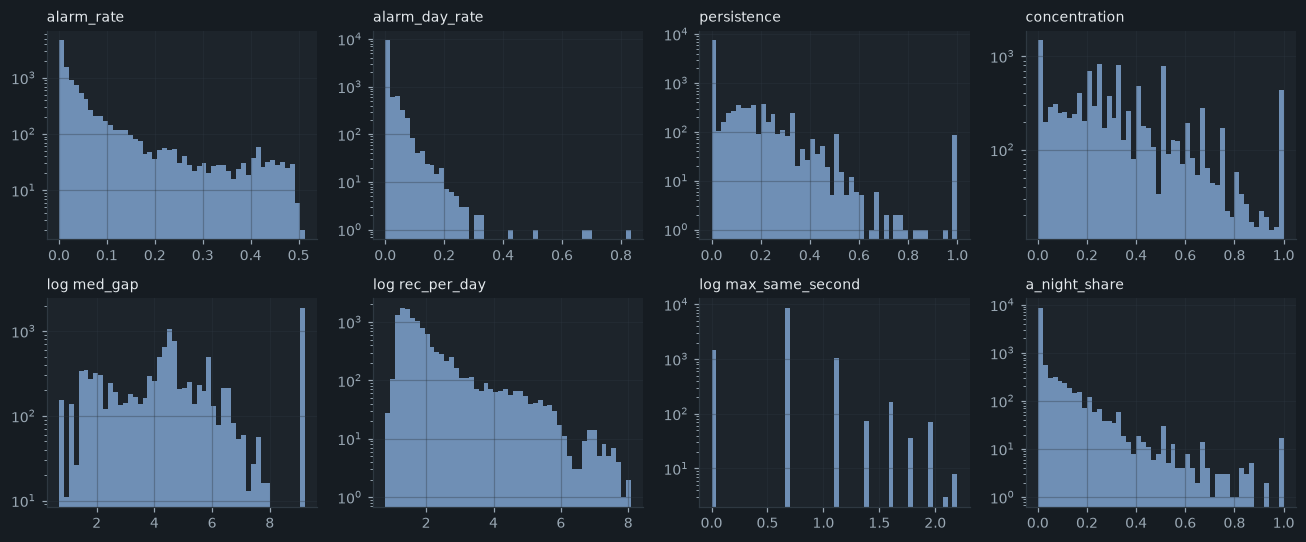

In [15]:
show = ["alarm_rate", "alarm_day_rate", "persistence", "concentration",
        "med_gap", "rec_per_day", "max_same_second", "a_night_share"]
fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for ax, f in zip(axes.ravel(), show):
    v = df[f].replace([np.inf, -np.inf], np.nan).dropna()
    if f in LOG_SCALE:
        v = np.log1p(v)
    ax.hist(v, bins=50, color=ACCENT[0])
    ax.set_title(("log " if f in LOG_SCALE else "") + f, color=TEXT, fontsize=9, loc="left")
    ax.set_yscale("log")
plt.tight_layout(); plt.show()

### 3.2. Что с чем связано

Матрица корреляций нужна для одного: убедиться, что мы не подали в UMAP один и
тот же признак три раза. Плотные блоки по единице означают дубли.

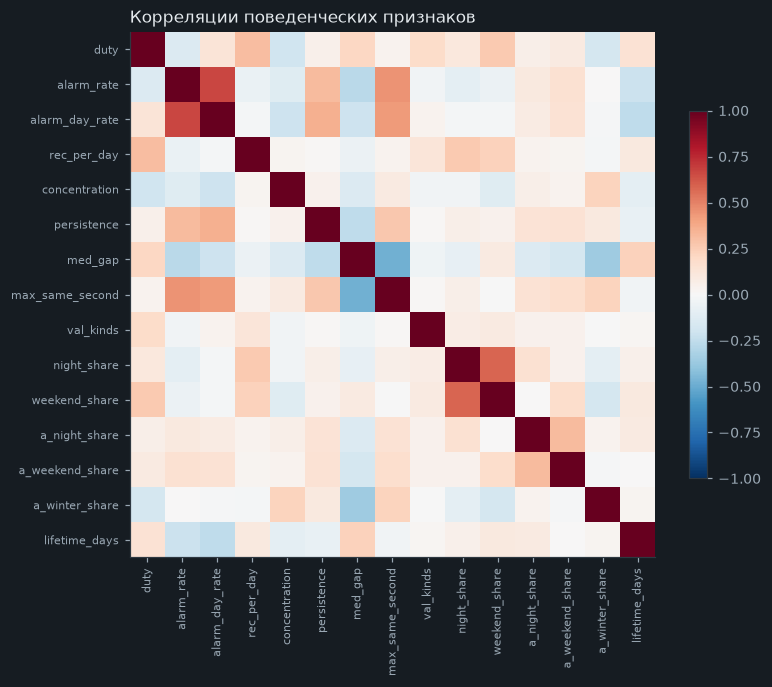

сильнее 0,8:


,,r


In [16]:
corr = df[BEHAVIOUR].replace([np.inf, -np.inf], np.nan).fillna(0).corr()
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(BEHAVIOUR)), BEHAVIOUR, rotation=90, fontsize=7)
ax.set_yticks(range(len(BEHAVIOUR)), BEHAVIOUR, fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7)
ax.set_title("Корреляции поведенческих признаков", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("сильнее 0,8:")
display(pairs[pairs.abs() > 0.8].sort_values(key=abs, ascending=False).to_frame("r").round(3))

## 4. UMAP

Пятнадцать признаков сворачиваем в две координаты. UMAP выбран, а не PCA,
потому что нас интересует локальная структура: группы похожих каналов. PCA
тянет дисперсию и сливает мелкие группы с крупными.

Перед UMAP обязательна стандартизация: признаки лежат в разных единицах, от
долей до тысяч дней, и без неё расстояние посчитает только `lifetime_days`.

Параметры: `n_neighbors=30` задаёт масштаб, на котором ищется структура,
`min_dist=0.0` прижимает точки внутри группы и разводит группы,
`random_state=42` вместе с `n_jobs=1` делает результат воспроизводимым.

Про воспроизводимость отдельно, потому что мы на ней обожглись.

Первые прогоны давали от 14 до 25 кластеров на одних и тех же данных. Сначала мы
думали на UMAP и на numba. Причина оказалась раньше по цепочке: **параллельный
join в DuckDB отдаёт строки в произвольном порядке**. Матрица признаков от этого
не меняется по содержанию, но меняется по порядку строк, а порядок строк меняет
список соседей в UMAP. Дальше HDBSCAN режет уже другую картинку.

Лечится одной строкой `ORDER BY` в запросе признаков. Она стоит в ячейке выше.

Вторая страховка на тот же случай: раскладка кэшируется в файл, имя которого
содержит отпечаток входной матрицы. Поменяются признаки, поменяется отпечаток, и
UMAP пересчитается сам. Молча подставить чужой кэш не получится.

Третья: ниже печатаются оба отпечатка. Если они меняются между запусками,
воспроизводимость сломана и выводы читать нельзя.

In [17]:
from sklearn.preprocessing import StandardScaler
import umap

X = df[BEHAVIOUR].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(float)
for i, f in enumerate(BEHAVIOUR):
    if f in LOG_SCALE:
        X[:, i] = np.log1p(X[:, i])
Xs = StandardScaler().fit_transform(X)

import numba

print("потоков numba:", numba.get_num_threads())

# Отпечаток входа. Раскладка кэшируется под него: если признаки изменились,
# кэш не подойдёт и UMAP пересчитается.
fingerprint = hashlib.md5(np.ascontiguousarray(Xs).tobytes()).hexdigest()[:16]
cache = OUT / f"umap_{fingerprint}.npy"

if cache.exists():
    emb = np.load(cache)
    print("раскладка взята из кэша:", cache.name)
else:
    t0 = time.time()
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.0, n_components=2, metric="euclidean",
                        random_state=SEED, n_jobs=1)
    emb = reducer.fit_transform(Xs)
    np.save(cache, emb)
    print("UMAP посчитан за", round(time.time() - t0, 1), "с и сохранён в", cache.name)

df["u1"], df["u2"] = emb[:, 0], emb[:, 1]
print("отпечаток входа:    ", fingerprint)
print("отпечаток раскладки:",
      hashlib.md5(np.ascontiguousarray(emb).tobytes()).hexdigest()[:16])

потоков numba: 1
раскладка взята из кэша: umap_7fa5b876e9d653ed.npy
отпечаток входа:     7fa5b876e9d653ed
отпечаток раскладки: edaf985031420985


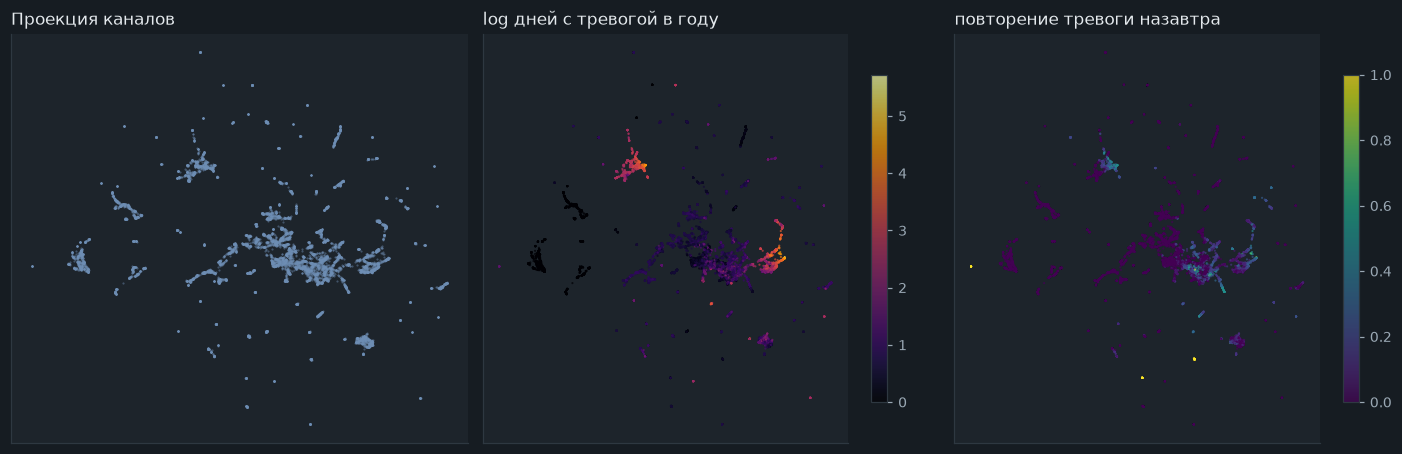

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

axes[0].scatter(df.u1, df.u2, s=2, c=ACCENT[0], alpha=0.45, linewidths=0)
axes[0].set_title("Проекция каналов", loc="left", color=TEXT)

sc = axes[1].scatter(df.u1, df.u2, s=2, c=np.log1p(df.alarm_day_rate * 365),
                     cmap="inferno", alpha=0.7, linewidths=0)
axes[1].set_title("log дней с тревогой в году", loc="left", color=TEXT)
fig.colorbar(sc, ax=axes[1], shrink=0.8)

sc = axes[2].scatter(df.u1, df.u2, s=2, c=df.persistence, cmap="viridis",
                     alpha=0.7, linewidths=0)
axes[2].set_title("повторение тревоги назавтра", loc="left", color=TEXT)
fig.colorbar(sc, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

Проверка на здравый смысл. Раскрасим ту же проекцию тем, чего UMAP не видел:
инженерной системой и типом датчика.

Если картинка распадётся ровно по типам, значит поведение полностью определяется
железом, и отдельная кластеризация не нужна. Если типы перемешаются, значит
поведение несёт свою информацию.

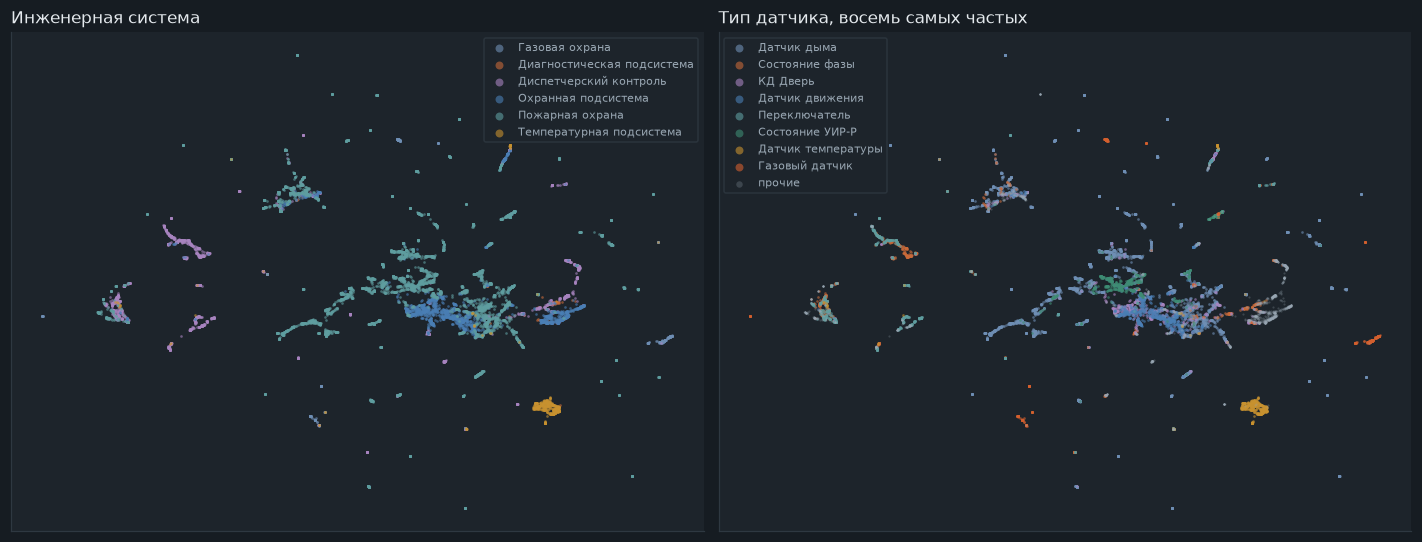

In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))

for i, (name, g) in enumerate(df.groupby("sys")):
    a1.scatter(g.u1, g.u2, s=3, alpha=0.6, linewidths=0,
               c=ACCENT[i % len(ACCENT)] if i < len(ACCENT) else RISK[i % len(RISK)], label=name)
a1.set_title("Инженерная система", loc="left", color=TEXT)
a1.legend(facecolor=PANEL, edgecolor=LINE, labelcolor=DIM, markerscale=3, fontsize=7)

top = df.stype.value_counts().head(8).index
for i, name in enumerate(top):
    g = df[df.stype == name]
    a2.scatter(g.u1, g.u2, s=3, alpha=0.6, linewidths=0, label=name,
               c=(ACCENT + RISK)[i % (len(ACCENT) + len(RISK))])
a2.scatter(df[~df.stype.isin(top)].u1, df[~df.stype.isin(top)].u2,
           s=2, alpha=0.25, c=DIM, linewidths=0, label="прочие")
a2.set_title("Тип датчика, восемь самых частых", loc="left", color=TEXT)
a2.legend(facecolor=PANEL, edgecolor=LINE, labelcolor=DIM, markerscale=3, fontsize=7)

for ax in (a1, a2):
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); plt.show()

## 5. Кластеризация

HDBSCAN, а не k-means. Причины две.

1. Число кластеров заранее неизвестно, и подбирать его локтем на глаз хуже, чем
   дать алгоритму найти его самому.
2. Часть каналов не принадлежит ни одной группе. k-means обязан приписать каждую
   точку к кластеру, HDBSCAN помечает её шумом. Шум здесь полезен: это и есть
   каналы с редким поведением.

Размер `min_cluster_size` подбираем: он задаёт, что мы согласны называть группой.

In [20]:
from sklearn.cluster import HDBSCAN

grid = []
for mcs in (60, 100, 150, 250, 400):
    lab = HDBSCAN(min_cluster_size=mcs, min_samples=20).fit_predict(emb)
    grid.append({
        "min_cluster_size": mcs,
        "кластеров": len(set(lab)) - (1 if -1 in lab else 0),
        "шум": int((lab == -1).sum()),
        "доля шума": round(float((lab == -1).mean()), 3),
    })
display(pd.DataFrame(grid))

,min_cluster_size,кластеров,шум,доля шума
0,60,57,1567,0.136
1,100,37,2004,0.174
2,150,20,1064,0.093
3,250,16,1428,0.124
4,400,5,1208,0.105


кластеров: 20 | шум: 1064


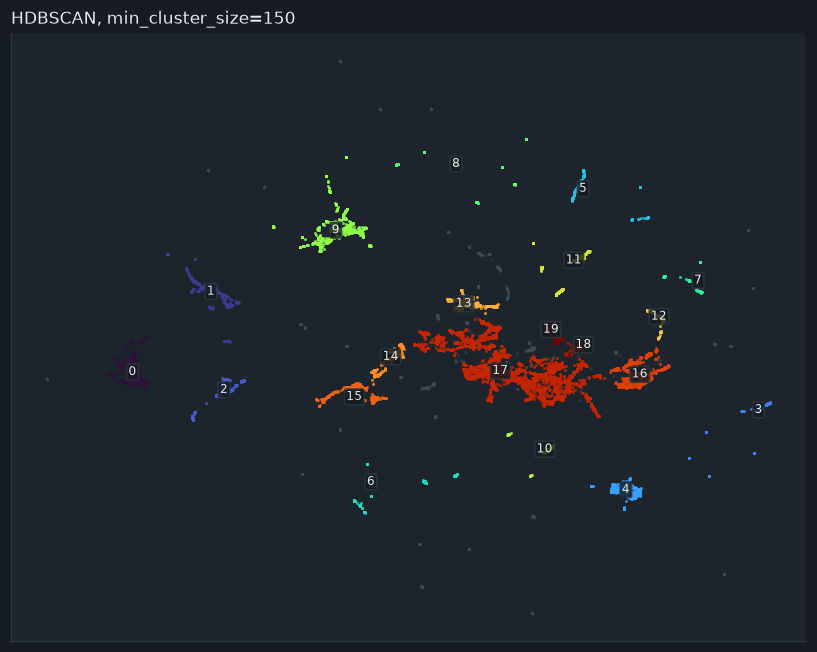

In [21]:
MIN_CLUSTER_SIZE = 150
labels = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=20).fit_predict(emb)
df["cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("кластеров:", n_clusters, "| шум:", int((labels == -1).sum()))

fig, ax = plt.subplots(figsize=(7.5, 6))
noise = df[df.cluster == -1]
ax.scatter(noise.u1, noise.u2, s=3, c="#3E4A55", alpha=0.5, linewidths=0, label="шум")
cmap = plt.get_cmap("turbo")
for i, cl in enumerate(sorted(c for c in set(labels) if c != -1)):
    g = df[df.cluster == cl]
    ax.scatter(g.u1, g.u2, s=4, alpha=0.8, linewidths=0, color=cmap(i / max(n_clusters - 1, 1)))
    ax.annotate(str(cl), (g.u1.median(), g.u2.median()), color=TEXT, fontsize=8,
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.15", fc=BG, ec=LINE, alpha=0.8))
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title(f"HDBSCAN, min_cluster_size={MIN_CLUSTER_SIZE}", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

### 5.1. Портрет каждого кластера

Для каждого кластера считаем медианы поведенческих признаков и смотрим, из
каких типов датчиков он собран.

Колонка `чистота` показывает долю самого частого типа датчика. Чистота около
единицы означает, что кластер просто повторил тип. Чистота ниже 0,5 означает,
что кластер собрал разные датчики по общему поведению, и это интересный случай.

In [22]:
def cluster_profile(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for cl, g in frame.groupby("cluster"):
        vc = g.stype.value_counts(normalize=True)
        rows.append({
            "кластер": cl,
            "каналов": len(g),
            "чистота": round(float(vc.iloc[0]), 2),
            "топ_тип": vc.index[0],
            "систем": g.sys.nunique(),
            "объектов": g.oid.nunique(),
            "тревог_в_год": round(float((g.alarm_day_rate * 365).median()), 1),
            "доля_тревог": round(float(g.alarm_rate.median()), 4),
            "повтор": round(float(g.persistence.median()), 2),
            "пачка": int(g.max_same_second.median()),
            "концентрация": round(float(g.concentration.median()), 2),
            "ночь": round(float(g.a_night_share.median()), 2),
            "зима": round(float(g.a_winter_share.median()), 2),
            "молчит": round(float(g.silent.mean()), 2),
            "лет": round(float(g.lifetime_days.median() / 365), 1),
        })
    return pd.DataFrame(rows).set_index("кластер").sort_values("тревог_в_год", ascending=False)


profile = cluster_profile(df)
display(profile)

,каналов,чистота,топ_тип,систем,объектов,тревог_в_год,доля_тревог,повтор,пачка,концентрация,ночь,зима,молчит,лет
кластер,,,,,,,,,,,,,,
12,256,0.81,Состояние вентилятора,3,21,18.1,0.1129,0.12,3,0.08,0.08,0.26,0.00,6.4
16,779,0.48,КД АВ,6,64,16.3,0.3085,0.12,1,0.07,0.02,0.19,0.00,7.2
9,842,0.57,Датчик дыма,4,7,14.7,0.1064,0.14,1,0.25,0.00,0.33,0.01,0.5
4,563,0.97,Датчик температуры,3,37,2.1,0.0137,0.08,1,0.20,0.06,0.25,0.00,7.4
10,198,0.74,Датчик дыма,4,22,1.9,0.0657,0.29,2,0.28,0.03,0.88,0.00,6.4
18,159,0.96,Датчик дыма,2,14,1.9,0.1237,0.12,1,0.51,0.02,0.90,0.00,6.4
3,268,0.77,Газовый датчик,3,13,1.7,0.0001,0.00,1,0.23,0.00,0.20,0.00,4.6
6,282,0.51,Газовый датчик,5,19,1.4,0.0054,0.00,1,0.44,0.00,0.10,0.00,6.5
15,442,0.99,Датчик дыма,1,6,1.2,0.0273,0.00,1,0.40,0.00,0.20,0.00,4.1


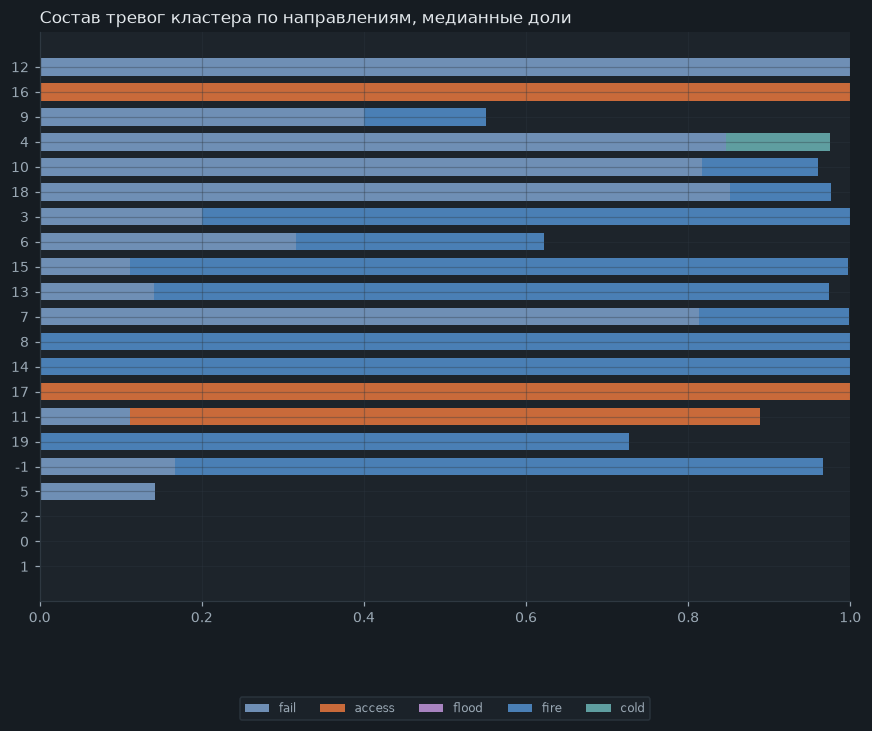

In [23]:
dirs = df.groupby("cluster")[["sh_fail", "sh_access", "sh_flood", "sh_fire", "sh_cold"]].median()
dirs = dirs.loc[profile.index]

fig, ax = plt.subplots(figsize=(8, max(3.5, 0.32 * len(dirs))))
left = np.zeros(len(dirs))
for i, c in enumerate(dirs.columns):
    ax.barh([str(i) for i in dirs.index], dirs[c], left=left, height=0.7,
            color=ACCENT[i], label=c.replace("sh_", ""))
    left += dirs[c].to_numpy()
ax.set_title("Состав тревог кластера по направлениям, медианные доли", loc="left", color=TEXT)
ax.legend(facecolor=PANEL, edgecolor=LINE, labelcolor=DIM, fontsize=8, ncols=5,
          loc="lower center", bbox_to_anchor=(0.5, -0.22))
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 6. Какие кластеры нам интересны

«Интересный» здесь не оценочное слово. Кластер интересен, если он меняет
что-то в решении: даёт признак, меняет разметку или показывает слепую зону.

Отбираем по пяти правилам. Пороги «шумности» и «липкости» берём как верхний
квинтиль распределения самих кластеров, а не назначаем числом: назначенное число
пришлось бы защищать, а квантиль описывает выборку.

1. **Шумный кластер.** Много дней с тревогой в году. ТЗ §2 прямо называет ложные
   тревоги проблемой: «ложные тревоги составляют значительную часть всех
   срабатываний». Такие каналы дают Precision просадку.
2. **Липкий кластер.** Тревога назавтра повторяется чаще, чем у 80 % кластеров.
   Событие тянется несколько суток подряд, то есть канал сообщает не о
   происшествии, а о собственном состоянии.
3. **Смешанный кластер.** Чистота по типу датчика ниже 0,55. Поведение победило
   железо, и это новая информация сверх справочника.
4. **Молчаливый кластер.** Канал пишет в журнал, но не тревожит ни разу за годы.
   Для модели он бесполезен, а для эксплуатации это вопрос: датчик исправен или
   его давно никто не проверял.
5. **Одноразовый кластер.** Половина и больше всех тревог канала пришлась на
   один день. Это не режим работы, а единичное происшествие или разовый сбой.

Отдельно смотрим на шум HDBSCAN. Это не брак разбиения: точки, не попавшие ни в
одну группу, и есть каналы с редким поведением.

In [24]:
# Строка -1 это шум HDBSCAN, а не кластер. В отборе она не участвует.
clusters = profile.drop(index=-1, errors="ignore")
noise_row = profile.loc[[-1]] if -1 in profile.index else None

# Пороги берём из распределения самих кластеров, а не назначаем на глаз.
LOUD = clusters.тревог_в_год.quantile(0.80)
STUCK = clusters.повтор.quantile(0.80)
MIXED = 0.55
print(f"порог шумности:  {LOUD:.1f} дней с тревогой в году")
print(f"порог повтора:   {STUCK:.2f}")


def tags(row):
    """Метка описывает поведение. Состав по типам датчиков идёт отдельной колонкой:
    смешанность говорит, откуда кластер собран, но риска сама по себе не несёт."""
    out = []
    if row.тревог_в_год >= LOUD:
        out.append("шумный")
    if row.повтор >= STUCK and row.тревог_в_год >= 1:
        out.append("липкий")
    if row.молчит > 0.5:
        out.append("молчаливый")
    if row.концентрация >= 0.5:
        out.append("одноразовый")
    return ", ".join(out) or "обычный"


clusters = clusters.assign(метка=clusters.apply(tags, axis=1),
                           смешанный=clusters.чистота < MIXED)
profile.loc[clusters.index, "метка"] = clusters.метка
if noise_row is not None:
    profile.loc[-1, "метка"] = "шум HDBSCAN"

interesting = clusters[clusters.метка != "обычный"]
display(interesting[["каналов", "чистота", "смешанный", "топ_тип", "тревог_в_год",
                     "доля_тревог", "повтор", "концентрация", "молчит", "лет", "метка"]])
print("интересных кластеров:", len(interesting), "из", len(clusters))
print("каналов в них:", int(interesting.каналов.sum()),
      f"({interesting.каналов.sum() / len(df):.0%} сети)")
if noise_row is not None:
    print("в шуме:", int(noise_row.каналов.iloc[0]), "каналов с редким поведением")
print("смешанных по составу:", int(clusters.смешанный.sum()), "кластеров")

порог шумности:  1.9 дней с тревогой в году
порог повтора:   0.12


,каналов,чистота,смешанный,топ_тип,тревог_в_год,доля_тревог,повтор,концентрация,молчит,лет,метка
кластер,,,,,,,,,,,
12,256,0.81,False,Состояние вентилятора,18.1,0.1129,0.12,0.08,0.00,6.4,"шумный, липкий"
16,779,0.48,True,КД АВ,16.3,0.3085,0.12,0.07,0.00,7.2,"шумный, липкий"
9,842,0.57,False,Датчик дыма,14.7,0.1064,0.14,0.25,0.01,0.5,"шумный, липкий"
4,563,0.97,False,Датчик температуры,2.1,0.0137,0.08,0.20,0.00,7.4,шумный
10,198,0.74,False,Датчик дыма,1.9,0.0657,0.29,0.28,0.00,6.4,липкий
18,159,0.96,False,Датчик дыма,1.9,0.1237,0.12,0.51,0.00,6.4,"липкий, одноразовый"
7,166,0.99,False,Датчик дыма,1.1,0.0298,0.29,0.36,0.00,6.4,липкий
5,297,0.25,True,Переключатель,0.2,0.0035,0.00,1.00,0.00,4.6,одноразовый
2,290,0.64,False,Переключатель,0.0,0.0000,0.00,0.00,1.00,7.4,молчаливый


интересных кластеров: 11 из 20
каналов в них: 4699 (41% сети)
в шуме: 1064 каналов с редким поведением
смешанных по составу: 7 кластеров


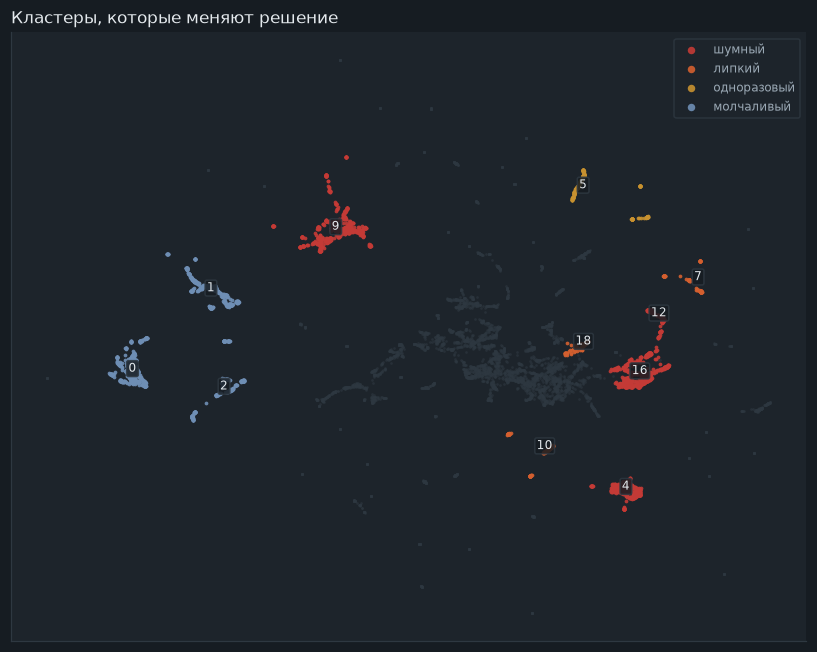

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(df.u1, df.u2, s=3, c="#2E3841", alpha=0.6, linewidths=0)
palette = {"шумный": RISK[3], "липкий": RISK[2], "смешанный": ACCENT[2],
           "молчаливый": ACCENT[0], "одноразовый": RISK[1]}
seen = set()
for cl, row in interesting.iterrows():
    g = df[df.cluster == cl]
    key = row.метка.split(",")[0]
    ax.scatter(g.u1, g.u2, s=6, alpha=0.9, linewidths=0, color=palette.get(key, RISK[0]),
               label=key if key not in seen else None)
    seen.add(key)
    ax.annotate(str(cl), (g.u1.median(), g.u2.median()), color=TEXT, fontsize=8, ha="center",
                bbox=dict(boxstyle="round,pad=0.15", fc=BG, ec=LINE, alpha=0.85))
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.legend(facecolor=PANEL, edgecolor=LINE, labelcolor=DIM, markerscale=2, fontsize=8)
ax.set_title("Кластеры, которые меняют решение", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

### 6.1. Загляни внутрь кластера

Медианы скрывают детали. Посмотрим на сами каналы в самых шумных группах.

In [26]:
for cl in interesting.sort_values("тревог_в_год", ascending=False).head(3).index:
    g = df[df.cluster == cl]
    print(f"\n=== кластер {cl}: {profile.loc[cl, 'метка']} | "
          f"{len(g)} каналов | {profile.loc[cl, 'топ_тип']} ===")
    display(g.nlargest(5, "alarm_day_rate")[
        ["cid", "sys", "stype", "nm", "oid", "alarm_n", "alarm_day_rate",
         "persistence", "concentration"]].round(3))


=== кластер 12: шумный, липкий | 256 каналов | Состояние вентилятора ===


,cid,sys,stype,nm,oid,alarm_n,alarm_day_rate,persistence,concentration
5880,229639,Диспетчерский контроль,Состояние вентилятора,В9 ПК126,5333,1948.0,0.132,0.214,0.038
5930,229705,Диспетчерский контроль,Состояние вентилятора,В2 ПК23 ; ПК18,5333,1588.0,0.130,0.191,0.038
5886,229647,Диспетчерский контроль,Состояние вентилятора,В7 ПК98,5333,1866.0,0.127,0.195,0.033
5890,229652,Диспетчерский контроль,Состояние вентилятора,В6 ПК86,5333,1770.0,0.126,0.193,0.035
5927,229701,Диспетчерский контроль,Состояние вентилятора,В3 ПК41,5333,1558.0,0.126,0.180,0.037



=== кластер 16: шумный, липкий | 779 каналов | КД АВ ===


,cid,sys,stype,nm,oid,alarm_n,alarm_day_rate,persistence,concentration
3330,196627,Диспетчерский контроль,Состояние насоса,АНС2 Н1 ПК100 Обр,5122,35983.0,0.834,0.959,0.006
3329,196625,Диспетчерский контроль,Состояние насоса,АНС1 Н3 ПК137 Г.1 ПК18 Обр,5122,20217.0,0.686,0.875,0.009
3373,196672,Диспетчерский контроль,Состояние насоса,АНС4 Н1 ПК231 Г.3 ПК18,5122,20681.0,0.675,0.839,0.010
375,77836,Охранная подсистема,КД АВ,КД АВ ПК765,3215,18205.0,0.514,0.616,0.005
88,3067,Охранная подсистема,КД АВ,КД АВ ПК177,28,7211.0,0.419,0.566,0.007



=== кластер 9: шумный, липкий | 842 каналов | Датчик дыма ===


,cid,sys,stype,nm,oid,alarm_n,alarm_day_rate,persistence,concentration
10779,333746,Диспетчерский контроль,Состояние насоса,Н3 ПК1090,5963,215.0,0.282,0.593,0.158
10799,333782,Диспетчерский контроль,Состояние насоса,Н2 ПК1195,5963,485.0,0.249,0.500,0.223
10506,330594,Охранная подсистема,КД Дверь,КД отс.дверь ПК1087,5961,187.0,0.212,0.469,0.053
10713,333642,Диспетчерский контроль,Состояние насоса,Н2 ПК1050,5963,171.0,0.207,0.372,0.287
10461,330475,Охранная подсистема,КД Дверь,КД отс.дверь ПК984,5961,141.0,0.202,0.455,0.043


### 6.2. Насосы: сценарий заказчика в данных

Заказчик на QA-сессии описал режим, которого нет в ТЗ. Коллекторы пересекаются,
и течь у одной насосной станции из-за разуклонки уходит дальше. Срабатывает
насос не там, где течь. Второй признак того же: насос мигает, включается и
выключается подряд, и исправный насос так не работает.

Проверяем, видно ли это в выгрузке.

In [27]:
pump = df[df.stype == "Состояние насоса"]
rest = df[df.stype != "Состояние насоса"]

cmp = pd.DataFrame({
    "насосы": [len(pump), pump.alarm_rate.median(), (pump.alarm_day_rate * 365).median(),
               pump.max_same_second.median(), pump.persistence.median()],
    "остальные": [len(rest), rest.alarm_rate.median(), (rest.alarm_day_rate * 365).median(),
                  rest.max_same_second.median(), rest.persistence.median()],
}, index=["каналов", "доля тревожных записей", "дней с тревогой в году",
          "тревог в одну секунду", "повтор назавтра"])
display(cmp.round(3))

# Ни один кластер насосами не назван: их всего 180 на сеть в 11 485 каналов,
# и они растворяются в больших группах. Смотрим, в какие именно они попали.
where = (pump.cluster.value_counts().rename("насосов").to_frame()
             .join(profile[["каналов", "топ_тип", "тревог_в_год", "доля_тревог", "метка"]]))
where["доля_кластера"] = (where.насосов / where.каналов).round(3)
display(where)

,насосы,остальные
каналов,180.000,11305.000
доля тревожных записей,0.372,0.018
дней с тревогой в году,21.030,1.107
тревог в одну секунду,5.000,1.000
повтор назавтра,0.149,0.000


,насосов,каналов,топ_тип,тревог_в_год,доля_тревог,метка,доля_кластера
cluster,,,,,,,
16,124,779,КД АВ,16.3,0.3085,"шумный, липкий",0.159
10,46,198,Датчик дыма,1.9,0.0657,липкий,0.232
9,9,842,Датчик дыма,14.7,0.1064,"шумный, липкий",0.011
-1,1,1064,Датчик дыма,0.9,0.0185,шум HDBSCAN,0.001


насосных каналов: 180


,макс_за_сутки,медиана_за_сутки,суток
cid,,,
103910,3554,10.0,917
115798,3458,4.0,227
115556,3417,2.0,531
115797,3141,4.0,233
115807,3105,4.0,229
115806,2204,4.0,238
215891,2151,2.0,999
115801,1459,4.0,215


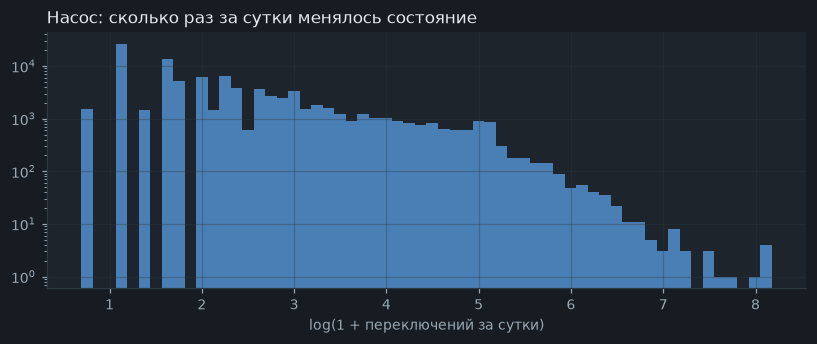

каналов в верхних 5 % по миганию: 9


In [28]:
# «Мигание»: сколько раз за сутки насос менял состояние. Считаем прямо по журналу.
flap = con.sql("""
SELECT b.cid, b.dd, count(*) AS switches
FROM base b
JOIN ch c ON c.ид_канала_данных = b.cid
WHERE c.тип_датчика = 'Состояние насоса'
GROUP BY 1, 2
""").df()

per_channel = flap.groupby("cid").switches.agg(["max", "median", "size"])
per_channel.columns = ["макс_за_сутки", "медиана_за_сутки", "суток"]
print("насосных каналов:", len(per_channel))
display(per_channel.nlargest(8, "макс_за_сутки"))

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(np.log1p(flap.switches), bins=60, color=ACCENT[3])
ax.set_xlabel("log(1 + переключений за сутки)")
ax.set_title("Насос: сколько раз за сутки менялось состояние", loc="left", color=TEXT)
ax.set_yscale("log")
plt.tight_layout(); plt.show()

hot = per_channel[per_channel.макс_за_сутки >= per_channel.макс_за_сутки.quantile(0.95)]
print("каналов в верхних 5 % по миганию:", len(hot))

Режим виден, и разрыв огромный. Насос тревожит в среднем 21 день в году против
1,1 дня у остальных каналов, а доля тревожных записей у него 37 % против 1,8 %.
В одну секунду насос успевает дать пять тревог, остальные каналы одну.

Самое интересное в хвосте. У отдельных каналов состояние меняется больше трёх
тысяч раз за сутки, то есть чаще раза в полминуты. Это и есть мигание, про
которое говорил заказчик.

**Признак для модели готов:** число переключений насоса за окно. Он считается
одним запросом и прямо ложится в направление «Риск подтопления».

Отдельно стоит заметить, что кластеризация насосы не выделила. Их 180 на сеть в
11 485 каналов, и HDBSCAN растворил их в больших группах. Это ограничение метода,
а не данных: редкий, но важный тип надо смотреть отдельным срезом. Кластеризация
ищет большие группы, а не важные.

### 6.3. Каналы, которые молчат годами

каналов без единой тревоги: 1451 (12.6% сети)
медианный срок жизни: 7.3 лет
медиана записей в журнале: 1823


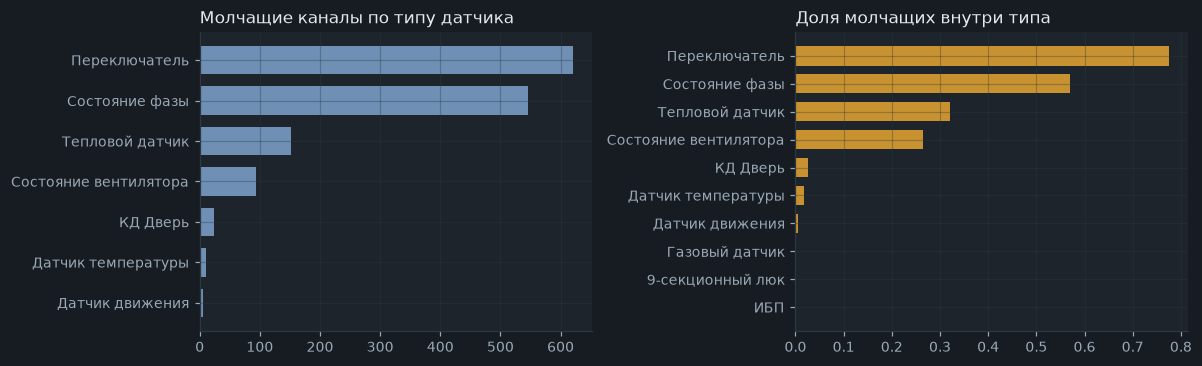

In [29]:
silent = df[df.alarm_n == 0]
print("каналов без единой тревоги:", len(silent), f"({len(silent)/len(df):.1%} сети)")
print("медианный срок жизни:", round(silent.lifetime_days.median() / 365, 1), "лет")
print("медиана записей в журнале:", int(silent.rec_n.median()))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
vc = silent.stype.value_counts().head(10)
a1.barh(vc.index[::-1], vc.values[::-1], color=ACCENT[0], height=0.7)
a1.set_title("Молчащие каналы по типу датчика", loc="left", color=TEXT)

share = (df.groupby("stype").apply(lambda g: (g.alarm_n == 0).mean())
           .sort_values(ascending=False).head(10))
a2.barh(share.index[::-1], share.values[::-1], color=RISK[1], height=0.7)
a2.set_title("Доля молчащих внутри типа", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

### 6.4. Канал ведёт себя не как его тип

Кластеры описывают группы. Отдельный канал-выброс они пропускают: он попадает в
шум или растворяется в большой группе.

Ищем такие каналы иначе. Для каждого типа датчика считаем центр его облака в
координатах UMAP и меряем, насколько канал от этого центра ушёл. Датчик дыма,
который ведёт себя как насос, является кандидатом на неисправность или на
ошибку в паспорте сети.

In [30]:
from scipy.spatial.distance import cdist

df["type_outlier"] = np.nan
for stype, g in df.groupby("stype"):
    if len(g) < 30:
        continue
    centre = g[["u1", "u2"]].median().to_numpy().reshape(1, -1)
    dist = cdist(g[["u1", "u2"]].to_numpy(), centre).ravel()
    scale = np.median(dist) or 1.0
    df.loc[g.index, "type_outlier"] = dist / scale

out = df.dropna(subset=["type_outlier"]).nlargest(15, "type_outlier")
display(out[["cid", "sys", "stype", "nm", "oid", "alarm_n", "alarm_day_rate",
             "persistence", "concentration", "type_outlier"]].round(3))

,cid,sys,stype,nm,oid,alarm_n,alarm_day_rate,persistence,concentration,type_outlier
10778,333743,Диспетчерский контроль,Состояние насоса,Н2 ПК1090,5963,93.0,0.085,0.294,0.366,76.239
10777,333742,Диспетчерский контроль,Состояние насоса,Н1 ПК1090,5963,189.0,0.169,0.457,0.201,71.087
10800,333785,Диспетчерский контроль,Состояние насоса,Н3 ПК1195,5963,153.0,0.170,0.438,0.222,71.069
10779,333746,Диспетчерский контроль,Состояние насоса,Н3 ПК1090,5963,215.0,0.282,0.593,0.158,70.874
10713,333642,Диспетчерский контроль,Состояние насоса,Н2 ПК1050,5963,171.0,0.207,0.372,0.287,70.839
10799,333782,Диспетчерский контроль,Состояние насоса,Н2 ПК1195,5963,485.0,0.249,0.500,0.223,70.814
10594,333435,Диспетчерский контроль,Состояние насоса,Н1 ПК0,5963,182.0,0.092,0.412,0.275,70.706
10596,333439,Диспетчерский контроль,Состояние насоса,Н3 ПК0,5963,180.0,0.085,0.438,0.333,70.374
10595,333436,Диспетчерский контроль,Состояние насоса,Н2 ПК0,5963,186.0,0.097,0.444,0.290,70.231
231,9376,Температурная подсистема,Датчик температуры,Темп. подвал холл ДП,99,162.0,0.008,0.200,0.772,47.661


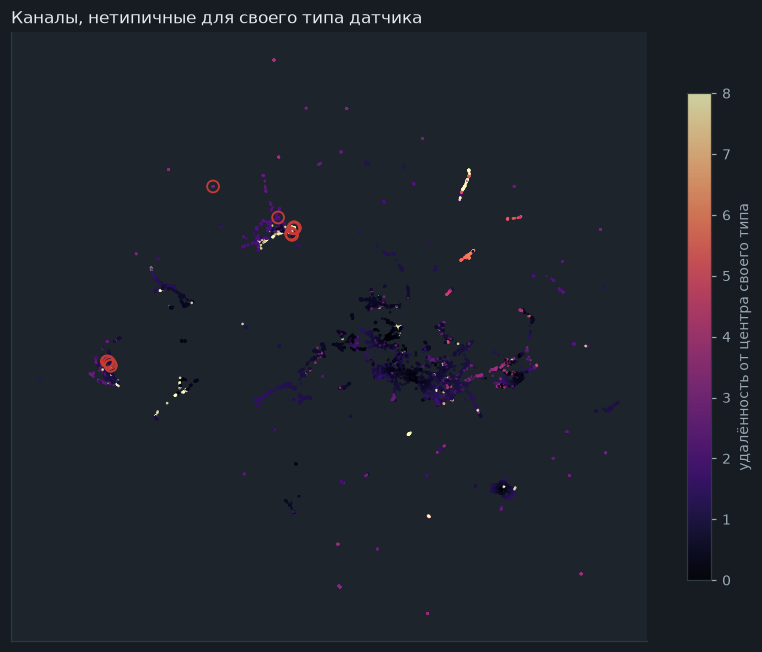

In [31]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sc = ax.scatter(df.u1, df.u2, s=3, c=df.type_outlier.fillna(0).clip(0, 8),
                cmap="magma", alpha=0.8, linewidths=0)
ax.scatter(out.u1, out.u2, s=60, facecolors="none", edgecolors=RISK[3], linewidths=1.2)
fig.colorbar(sc, ax=ax, shrink=0.8, label="удалённость от центра своего типа")
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Каналы, нетипичные для своего типа датчика", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

### 6.5. Где эти каналы стоят

Кластер живёт в признаковом пространстве, а бригада выезжает на пикет. Сводим
метку кластера к паре «объект и пикет», то есть к единице прогноза сервиса.

In [32]:
loud_clusters = interesting[interesting.метка.str.contains("шумный|липкий")].index
df["problem"] = df.cluster.isin(loud_clusters)

unit = (df.dropna(subset=["picket"])
          .groupby(["oid", "gal_key", "picket"])
          .agg(каналов=("cid", "size"),
               проблемных=("problem", "sum"),
               тревог=("alarm_n", "sum"),
               метры=("distance_m", "median"))
          .reset_index())
unit["доля_проблемных"] = (unit.проблемных / unit.каналов).round(2)

names = con.sql("SELECT ид_объект AS oid, диспетчерское_название_объекта AS объект FROM ob").df()
unit = unit.merge(names, on="oid", how="left")

print("пар объект-пикет:", len(unit))
print("пар, где проблемных каналов больше половины:", int((unit.доля_проблемных > 0.5).sum()))
display(unit.nlargest(12, "проблемных")[
    ["объект", "gal_key", "picket", "метры", "каналов", "проблемных",
     "доля_проблемных", "тревог"]])

пар объект-пикет: 3947
пар, где проблемных каналов больше половины: 701


,объект,gal_key,picket,метры,каналов,проблемных,доля_проблемных,тревог
3904,объект Гамма ДУ,-1.0,1089.0,10890.0,53,26,0.49,427.0
2857,объект Мю ДУ,-1.0,399.0,3990.0,47,18,0.38,5177.0
3873,объект Гамма ДУ,-1.0,28.0,280.0,55,16,0.29,378.0
2782,объект Каппа ДУ,-1.0,632.0,6320.0,37,15,0.41,4054.0
2541,объект Дзета ДУ,1.0,5.0,50.0,31,14,0.45,6391.0
1629,ДУ объект Кси,-1.0,60.0,600.0,27,12,0.44,6150.0
3699,объект Гамма ПС,-1.0,1050.0,10500.0,12,12,1.00,111.0
1199,объект Дельта,-1.0,305.0,3050.0,41,11,0.27,2387.0
2792,объект Каппа ДУ,-1.0,730.0,7300.0,37,11,0.30,3893.0
134,объект Каппа ОС,-1.0,848.0,8480.0,13,10,0.77,690.0


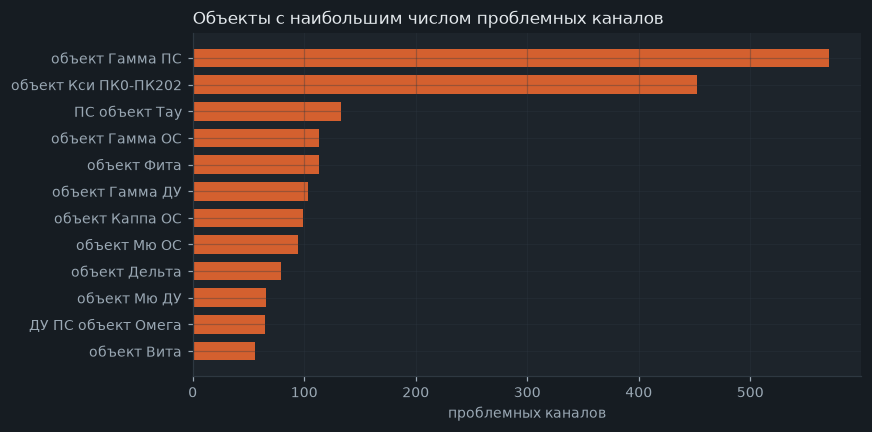

In [33]:
worst = unit.groupby("объект").agg(
    пикетов=("picket", "size"), проблемных=("проблемных", "sum"), тревог=("тревог", "sum")
).nlargest(12, "проблемных")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(worst.index[::-1], worst.проблемных[::-1], color=RISK[2], height=0.7)
ax.set_xlabel("проблемных каналов")
ax.set_title("Объекты с наибольшим числом проблемных каналов", loc="left", color=TEXT)
plt.tight_layout(); plt.show()

## 7. Что забрать в сервис

Тетрадь не является частью сервиса. В конвейер переезжают три вещи.

1. **Поведенческие признаки.** Пятнадцать штук из `BEHAVIOUR`. Они считаются
   одним запросом DuckDB за шесть секунд по всей выгрузке, значит в
   `app/features/` они лягут дёшево. Считать их надо в скользящих окнах 1, 24,
   168 и 720 часов, а не один раз на всю историю: модель обязана видеть
   состояние канала на момент расчёта, иначе будет утечка по времени.
2. **Метка кластера как признак.** Номер кластера сам по себе является входом
   модели: он сжимает пятнадцать чисел в одну категорию.
3. **Правило отбраковки.** Каналы из шумных кластеров не порождают заявку на
   общих основаниях: они тревожат постоянно, и бригада поедет впустую. Порог
   для них поднимается отдельно. Молчаливые каналы, наоборот, из прогноза
   выпадают и уходят в отчёт об обслуживании.

Таблица признаков и меток сохраняется в `notebooks/out/`, чтобы следующая
тетрадь не пересчитывала её заново.

In [34]:
keep = (["cid", "sys", "stype", "nm", "oid", "picket", "offset_m", "gallery", "gal_key",
         "distance_m"]
        + BEHAVIOUR + ["silent", "sh_fail", "sh_access", "sh_flood", "sh_fire", "sh_cold",
                       "u1", "u2", "cluster", "type_outlier", "problem"])
result = df[keep].copy()
result.to_parquet(OUT / "channel_features.parquet", index=False)
profile.to_csv(OUT / "cluster_profile.csv", encoding="utf-8")
unit.to_parquet(OUT / "unit_rollup.parquet", index=False)

print("сохранено в", OUT)
for f in sorted(OUT.iterdir()):
    print(" ", f.name, f"{f.stat().st_size/1024:.0f} КБ")

сохранено в C:\Users\IshikiI\Desktop\Coding\Hackathons\LCT2026\LCT2026\notebooks\out
  channel_features.parquet 1098 КБ
  cluster_profile.csv 2 КБ
  umap_7fa5b876e9d653ed.npy 90 КБ
  unit_rollup.parquet 49 КБ


## 8. Итог

Что тетрадь показала.

- **Дерево объектов замыкается.** Обновлённый справочник связывает все 11 485
  каналов с 78 объектами. Прежний обходной путь через номера пикетов больше не
  нужен.
- **Всплеск 2021 года это один объект, а не сеть.** Объект 5343 дал 73 % всех
  записей «Неисправен». Выбрасывать надо его за два года, а не два года целиком.
- **Поведение канала несёт информацию сверх типа датчика.** Часть кластеров
  собрана из разных типов, и разделило их поведение, а не железо.
- **Тревоги почти не липнут.** Повторение назавтра нигде не подходит к единице:
  медиана по кластерам держится ниже 0,35. Значит, «канал тревожит непрерывно,
  потому что сломан» в этих данных редкость, и строить разметку отказа на одной
  длине серии нельзя. Это отменяет нашу прежнюю гипотезу.
- **Насосы ведут себя иначе всех.** Доля тревожных записей у них 37 % против
  1,8 % у остальных каналов, а у отдельных состояние меняется больше трёх тысяч
  раз за сутки. Заказчик описал этот режим сам: исправный насос не мигает.
  Признак для направления «Риск подтопления» лежит готовым.
- **Кластеризация нашла большие группы, а не важные.** Насосы, самый яркий по
  поведению тип, в отдельный кластер не выделились: их слишком мало. Редкие типы
  надо смотреть отдельным срезом, и одной кластеризацией закрывать разведку
  нельзя.
- **Больше тысячи каналов не тревожили ни разу за 7,5 года.** Для обучения они
  балласт, а для эксплуатации вопрос: датчик исправен или давно мёртв. Проверить
  их дешевле, чем ждать отказа.
- **Есть каналы, нетипичные для своего типа.** Они попадают в кандидаты на
  проверку паспорта сети.

Чего тетрадь не делает. Она не обучает модель и не меряет Precision и Recall.
Кластеризация обучения без учителя не заменяет: она описывает данные и готовит
признаки. Обучение делает человек, и разбиение там только по времени.